# 🏠 House Prices — Regressão & Avaliação
**Responsável:** Luis Felipe F. Vieira  
**Dataset:** [Kaggle - House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)  
**Objetivo:** Treinar modelos de Regressão Linear (Simples e Múltipla) para prever o preço de venda (`SalePrice`) e avaliar seu desempenho com métricas e visualizações.

---

## 📦 0. Importações

Importamos todas as bibliotecas necessárias para manipulação de dados, modelagem e visualização.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


---
## 📂 1. Carregamento dos Dados

Carregamos o arquivo `train_processed.csv`, gerado pelo notebook de **EDA & Feature Engineering** (`01_feature_engineering.ipynb`).  
Este dataset já passou por imputação de valores faltantes, normalização e encoding de variáveis categóricas — garantindo consistência com o restante do pipeline.

> ⚠️ Certifique-se de ter executado o notebook `01_feature_engineering.ipynb` antes de rodar este.

In [2]:
# Carrega o dataset processado (gerado pelo notebook 01)
df_full = pd.read_csv(r'..\data\train_processed.csv')

# Seleciona apenas as colunas numericas originais (sem dummies OHE)
# As features ja estao normalizadas e sem valores nulos
NUMERIC_COLS = [
    'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
    'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
    'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
    'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
    'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
    'MoSold', 'YrSold', 'SalePrice'
]

df_num = df_full[NUMERIC_COLS].copy()

print(f'Shape do dataset: {df_num.shape}')
print(f'Valores nulos: {df_num.isnull().sum().sum()}')
print(f'\nPrimeiras linhas:')
df_num.head()

Shape do dataset: (1458, 37)
Valores nulos: 0

Primeiras linhas:


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,0.073426,-0.221328,-0.203934,0.658506,-0.517649,1.052959,0.880362,0.523937,0.617283,-0.288867,...,-0.750831,0.225982,-0.359603,-0.11642,-0.270407,-0.063709,-0.087748,-1.601578,0.138375,208500
1,-0.871868,0.491760,-0.087252,-0.068293,2.177825,0.158428,-0.428115,-0.570739,1.245719,-0.288867,...,1.627328,-0.708304,-0.359603,-0.11642,-0.270407,-0.063709,-0.087748,-0.490155,-0.614427,181500
2,0.073426,-0.078710,0.080162,0.658506,-0.517649,0.986698,0.831900,0.334044,0.108989,-0.288867,...,-0.750831,-0.065025,-0.359603,-0.11642,-0.270407,-0.063709,-0.087748,0.991743,0.138375,223500
3,0.309749,-0.459024,-0.092325,0.658506,-0.517649,-1.862551,-0.718888,-0.570739,-0.514826,-0.288867,...,-0.750831,-0.172238,4.089589,-0.11642,-0.270407,-0.063709,-0.087748,-1.601578,-1.367230,140000
4,0.073426,0.681917,0.385566,1.385305,-0.517649,0.953567,0.734975,1.384039,0.499451,-0.288867,...,0.781406,0.578253,-0.359603,-0.11642,-0.270407,-0.063709,-0.087748,2.103167,0.138375,250000


---
## 🔧 2. Preparação dos Dados

O pré-processamento (imputação de nulos e normalização) foi realizado centralmente no notebook `01_feature_engineering.ipynb`.  
Aqui, trabalhamos apenas com as **features numéricas originais** do dataset, que já chegam sem valores faltantes, prontas para o treinamento.

O `SalePrice` (variável alvo) permanece em sua **escala original em dólares**, garantindo que as métricas MAE e RMSE sejam diretamente interpretáveis.

In [3]:
# Confirmacao: dataset pronto para modelagem
print(f'Features disponíveis: {df_num.shape[1] - 1}')
print(f'Amostras: {df_num.shape[0]}')
print(f'Valores nulos: {df_num.isnull().sum().sum()}')
df_num.describe()

Features disponíveis: 36
Amostras: 1458
Valores nulos: 0


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,...,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1.458000e+03,1458.000000
mean,-8.711215e-17,3.033696e-16,7.310110e-17,-2.875310e-16,3.009329e-16,3.041006e-15,3.321227e-15,1.462022e-17,1.388921e-16,-1.462022e-17,...,-4.873407e-17,-1.157434e-17,-3.289550e-17,5.117077e-17,4.020561e-17,3.898726e-17,2.436703e-17,3.655055e-17,1.503872e-14,180932.919067
std,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,...,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,79495.055285
min,-8.718675e-01,-2.313054e+00,-9.293940e-01,-3.702287e+00,-4.111615e+00,-3.287175e+00,-1.688130e+00,-5.707394e-01,-1.013878e+00,-2.888673e-01,...,-7.508307e-01,-7.083040e-01,-3.596031e-01,-1.164201e-01,-2.704072e-01,-6.370868e-02,-8.774840e-02,-1.972053e+00,-1.367230e+00,34900.000000
25%,-8.718675e-01,-4.590241e-01,-2.958088e-01,-7.950920e-01,-5.176494e-01,-5.704496e-01,-8.642741e-01,-5.707394e-01,-1.013878e+00,-2.888673e-01,...,-7.508307e-01,-7.083040e-01,-3.596031e-01,-1.164201e-01,-2.704072e-01,-6.370868e-02,-8.774840e-02,-4.901545e-01,-6.144272e-01,129925.000000
50%,-1.628977e-01,-3.117112e-02,-9.993458e-02,-6.829317e-02,-5.176494e-01,4.247014e-02,4.442027e-01,-5.707394e-01,-1.312950e-01,-2.888673e-01,...,-7.508307e-01,-3.330581e-01,-3.596031e-01,-1.164201e-01,-2.704072e-01,-6.370868e-02,-8.774840e-02,-1.196800e-01,1.383752e-01,163000.000000
75%,3.097488e-01,4.442211e-01,1.156741e-01,6.585057e-01,3.808421e-01,9.535670e-01,9.288238e-01,3.438177e-01,6.288352e-01,-2.888673e-01,...,5.898762e-01,3.331947e-01,-3.596031e-01,-1.164201e-01,-2.704072e-01,-6.370868e-02,-8.774840e-02,6.212690e-01,8.911776e-01,214000.000000
max,3.145628e+00,1.156840e+01,2.077809e+01,2.838902e+00,3.076316e+00,1.284875e+00,1.219596e+00,8.365390e+00,4.041335e+00,8.845683e+00,...,6.088371e+00,7.669634e+00,8.669640e+00,1.720544e+01,8.335794e+00,1.925726e+01,3.114396e+01,2.103167e+00,1.643980e+00,755000.000000


---
## ✂️ 3. Divisão Treino / Teste (80/20)

Dividimos os dados em **80% para treino** e **20% para teste**.  
- O modelo **aprende** com os dados de treino
- O modelo é **avaliado** com os dados de teste (dados nunca vistos)

Usamos `random_state=42` para garantir reprodutibilidade (os mesmos dados sempre que rodar).

In [4]:
# Variável alvo
TARGET = 'SalePrice'

# Remove a coluna alvo das features
X = df_num.drop(columns=[TARGET])
y = df_num[TARGET]

# Divisão 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Total de amostras:   {len(df_num)}')
print(f'Treino (80%):        {len(X_train)}')
print(f'Teste  (20%):        {len(X_test)}')

Total de amostras:   1458
Treino (80%):        1166
Teste  (20%):        292


---
## 📈 4. Regressão Linear Simples

Na **Regressão Linear Simples**, usamos apenas **uma variável** para prever o preço.  
Escolhemos `GrLivArea` (área habitável acima do solo em pés²), pois é uma das variáveis com maior correlação com `SalePrice`.

**Equação:** `SalePrice = β₀ + β₁ * GrLivArea`

In [5]:
# ── Feature escolhida para regressão simples ──
FEATURE_SIMPLES = 'GrLivArea'

X_train_simples = X_train[[FEATURE_SIMPLES]]
X_test_simples  = X_test[[FEATURE_SIMPLES]]

# Treino
modelo_simples = LinearRegression()
modelo_simples.fit(X_train_simples, y_train)

# Predições
y_pred_simples = modelo_simples.predict(X_test_simples)

# Coeficientes
print(f'Intercepto (β₀):  {modelo_simples.intercept_:,.2f}')
print(f'Coeficiente (β₁): {modelo_simples.coef_[0]:,.2f}')
print(f'\nInterpretação: para cada 1 pé² a mais, o preço aumenta ${modelo_simples.coef_[0]:,.2f}')

Intercepto (β₀):  180,721.67
Coeficiente (β₁): 60,219.92

Interpretação: para cada 1 pé² a mais, o preço aumenta $60,219.92


### 📊 Visualização — Regressão Simples

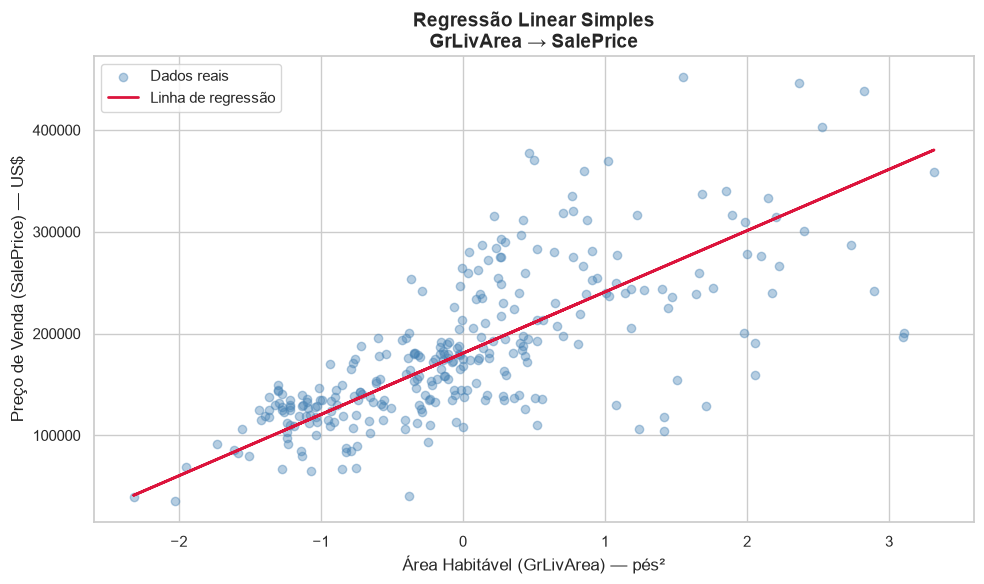

✅ Gráfico salvo: plot_regressao_simples.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test_simples, y_test, alpha=0.4, color='steelblue', label='Dados reais')
ax.plot(X_test_simples, y_pred_simples, color='crimson', linewidth=2, label='Linha de regressão')

ax.set_title('Regressão Linear Simples\nGrLivArea → SalePrice', fontsize=14, fontweight='bold')
ax.set_xlabel('Área Habitável (GrLivArea) — pés²')
ax.set_ylabel('Preço de Venda (SalePrice) — US$')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/plot_regressao_simples.png', dpi=150)
plt.show()
print('✅ Gráfico salvo: plot_regressao_simples.png')

---
## 📈 5. Regressão Linear Múltipla

Na **Regressão Linear Múltipla**, usamos **várias variáveis** simultaneamente para prever o preço.  
Isso permite ao modelo capturar mais informações e gerar previsões mais precisas.

**Equação:** `SalePrice = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ`

Selecionamos as features com maior correlação com `SalePrice`.

In [7]:
# Seleciona as 10 features com maior correlação com SalePrice
correlacoes = df_num.corr()[TARGET].abs().sort_values(ascending=False)
top_features = correlacoes.drop(TARGET).head(10).index.tolist()

print('Top 10 features mais correlacionadas com SalePrice:')
print(correlacoes.drop(TARGET).head(10).to_string())

Top 10 features mais correlacionadas com SalePrice:
OverallQual     0.795774
GrLivArea       0.734968
TotalBsmtSF     0.651153
GarageCars      0.641047
1stFlrSF        0.631530
GarageArea      0.629217
FullBath        0.562165
TotRmsAbvGrd    0.537769
YearBuilt       0.523608
YearRemodAdd    0.507717


In [8]:
# Treino com múltiplas features
X_train_multi = X_train[top_features]
X_test_multi  = X_test[top_features]

modelo_multiplo = LinearRegression()
modelo_multiplo.fit(X_train_multi, y_train)

# Predições
y_pred_multi = modelo_multiplo.predict(X_test_multi)

# Tabela de coeficientes
coef_df = pd.DataFrame({
    'Feature': top_features,
    'Coeficiente': modelo_multiplo.coef_
}).sort_values('Coeficiente', ascending=False)

print('Coeficientes do Modelo Múltiplo:')
print(coef_df.to_string(index=False))

Coeficientes do Modelo Múltiplo:
     Feature  Coeficiente
   GrLivArea 37442.981341
 OverallQual 22863.115383
 TotalBsmtSF 14669.825562
   YearBuilt  9304.541310
  GarageArea  8542.671232
YearRemodAdd  6653.017509
    1stFlrSF  4479.353307
  GarageCars   177.024180
TotRmsAbvGrd -3953.512208
    FullBath -5819.784010


---
## 📏 6. Métricas de Avaliação

Avaliamos ambos os modelos com três métricas:

| Métrica | O que mede | Ideal |
|---------|-----------|-------|
| **MAE** (Mean Absolute Error) | Erro médio em US$ | Quanto menor, melhor |
| **RMSE** (Root Mean Squared Error) | Penaliza erros grandes | Quanto menor, melhor |
| **R²** (Coeficiente de Determinação) | % da variância explicada pelo modelo | Quanto mais próximo de 1, melhor |

In [9]:
def calcular_metricas(y_real, y_pred, nome_modelo):
    """Calcula e exibe MAE, RMSE e R² para um modelo."""
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    
    print(f'\n{'='*45}')
    print(f'  {nome_modelo}')
    print(f'{'='*45}')
    print(f'  MAE  (Erro Médio Absoluto):      ${mae:>12,.2f}')
    print(f'  RMSE (Raiz do Erro Quadrático):  ${rmse:>12,.2f}')
    print(f'  R²   (Coef. Determinação):       {r2:>13.4f}')
    
    return {'modelo': nome_modelo, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Avalia ambos os modelos
m_simples  = calcular_metricas(y_test, y_pred_simples, 'Regressão Linear Simples')
m_multiplo = calcular_metricas(y_test, y_pred_multi,   'Regressão Linear Múltipla')

# DataFrame comparativo
metricas_df = pd.DataFrame([m_simples, m_multiplo]).set_index('modelo')
print('\n\n📊 Comparação Final:')
print(metricas_df.round(2).to_string())


  Regressão Linear Simples
  MAE  (Erro Médio Absoluto):      $   37,694.28
  RMSE (Raiz do Erro Quadrático):  $   52,992.87
  R²   (Coef. Determinação):              0.4916

  Regressão Linear Múltipla
  MAE  (Erro Médio Absoluto):      $   23,573.48
  RMSE (Raiz do Erro Quadrático):  $   31,540.51
  R²   (Coef. Determinação):              0.8199


📊 Comparação Final:
                                MAE      RMSE    R2
modelo                                             
Regressão Linear Simples   37694.28  52992.87  0.49
Regressão Linear Múltipla  23573.48  31540.51  0.82


---
## 📉 7. Plot — Preditos vs Reais

Este gráfico compara os valores **preditos** pelo modelo com os valores **reais**.  
- A linha diagonal vermelha representa a **previsão perfeita** (predito = real)
- Quanto mais próximos os pontos estiverem da linha, **melhor o modelo**

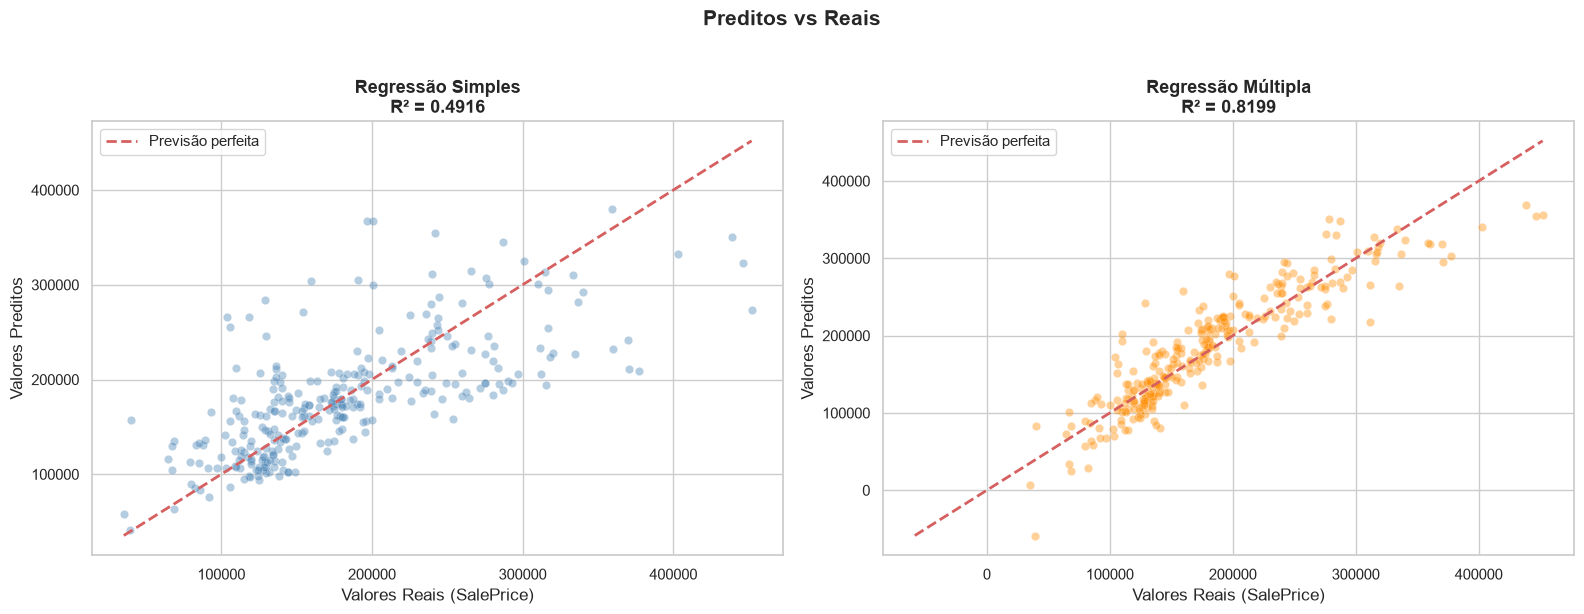

✅ Gráfico salvo: plot_preditos_vs_reais.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

modelos_plot = [
    (y_pred_simples, 'Regressão Simples', 'steelblue'),
    (y_pred_multi,   'Regressão Múltipla', 'darkorange')
]

for ax, (y_pred, titulo, cor) in zip(axes, modelos_plot):
    ax.scatter(y_test, y_pred, alpha=0.4, color=cor, edgecolors='white', linewidth=0.3)
    
    # Linha de previsão perfeita
    lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=2, label='Previsão perfeita')
    
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{titulo}\nR² = {r2:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Valores Reais (SalePrice)')
    ax.set_ylabel('Valores Preditos')
    ax.legend()

plt.suptitle('Preditos vs Reais', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/plot_preditos_vs_reais.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: plot_preditos_vs_reais.png')

---
## 📉 8. Plot — Análise de Resíduos

**Resíduos** = Valor Real − Valor Predito

Um bom modelo de regressão deve ter resíduos:
- Distribuídos **aleatoriamente** ao redor de zero (sem padrão)
- Com distribuição **aproximadamente normal**

Padrões nos resíduos indicam que o modelo está deixando de capturar alguma informação dos dados.

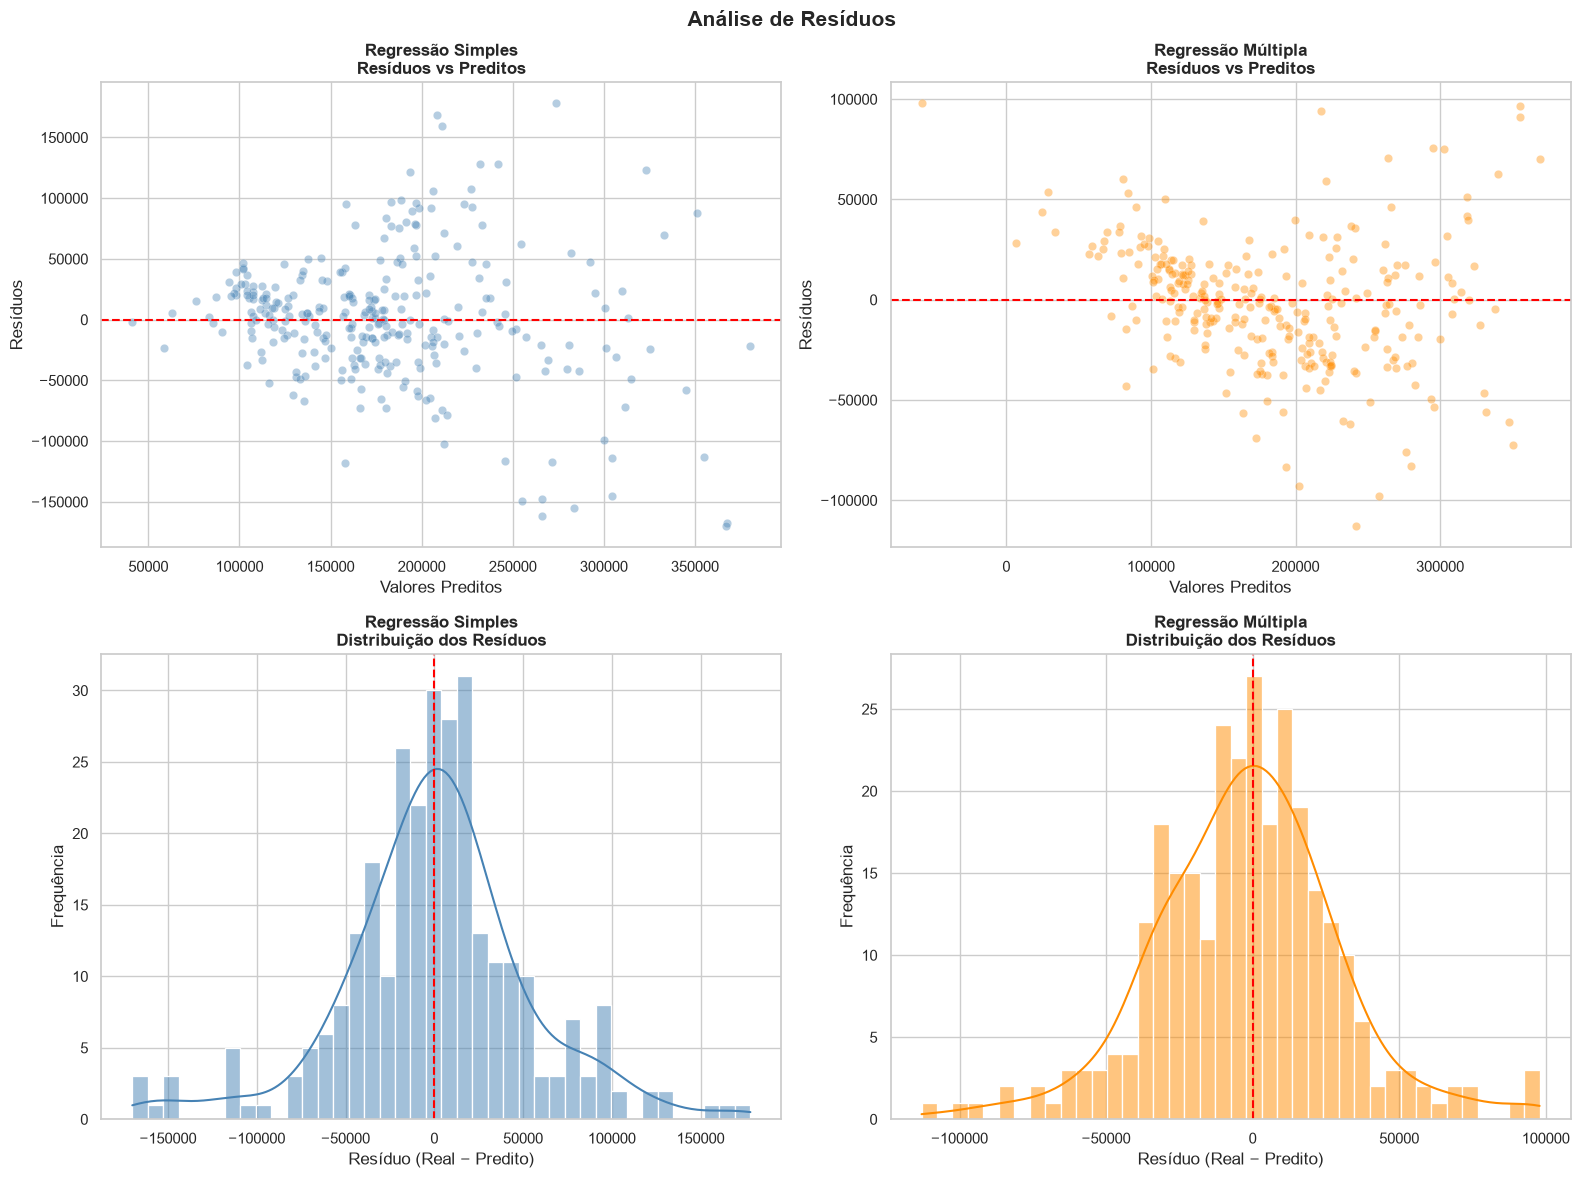

✅ Gráfico salvo: plot_residuos.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

modelos_residuos = [
    (y_pred_simples, 'Regressão Simples', 'steelblue'),
    (y_pred_multi,   'Regressão Múltipla', 'darkorange')
]

for col, (y_pred, titulo, cor) in enumerate(modelos_residuos):
    residuos = y_test - y_pred
    
    # ── Gráfico 1: Resíduos vs Preditos ──
    ax1 = axes[0, col]
    ax1.scatter(y_pred, residuos, alpha=0.4, color=cor, edgecolors='white', linewidth=0.3)
    ax1.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax1.set_title(f'{titulo}\nResíduos vs Preditos', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Valores Preditos')
    ax1.set_ylabel('Resíduos')
    
    # ── Gráfico 2: Distribuição dos Resíduos ──
    ax2 = axes[1, col]
    sns.histplot(residuos, kde=True, ax=ax2, color=cor, bins=40)
    ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax2.set_title(f'{titulo}\nDistribuição dos Resíduos', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Resíduo (Real − Predito)')
    ax2.set_ylabel('Frequência')

plt.suptitle('Análise de Resíduos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/plot_residuos.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: plot_residuos.png')

---
## 📊 9. Comparação Visual das Métricas

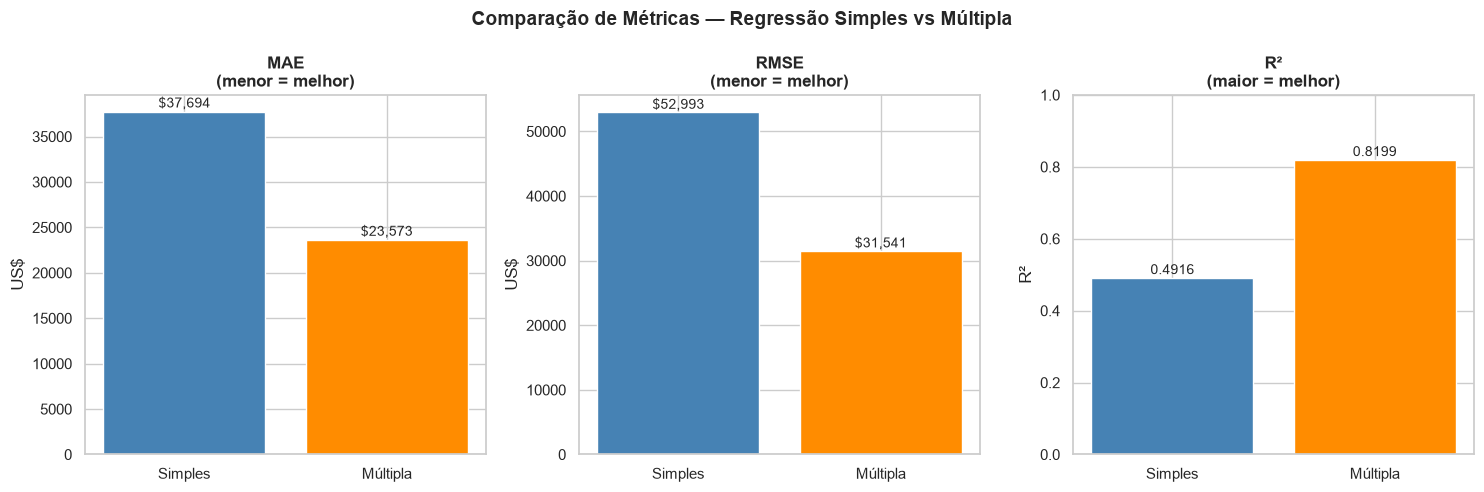

✅ Gráfico salvo: plot_comparacao_metricas.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

modelos_nomes = ['Simples', 'Múltipla']
cores = ['steelblue', 'darkorange']

# MAE
axes[0].bar(modelos_nomes, [m_simples['MAE'], m_multiplo['MAE']], color=cores)
axes[0].set_title('MAE\n(menor = melhor)', fontweight='bold')
axes[0].set_ylabel('US$')
for i, v in enumerate([m_simples['MAE'], m_multiplo['MAE']]):
    axes[0].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=10)

# RMSE
axes[1].bar(modelos_nomes, [m_simples['RMSE'], m_multiplo['RMSE']], color=cores)
axes[1].set_title('RMSE\n(menor = melhor)', fontweight='bold')
axes[1].set_ylabel('US$')
for i, v in enumerate([m_simples['RMSE'], m_multiplo['RMSE']]):
    axes[1].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=10)

# R²
axes[2].bar(modelos_nomes, [m_simples['R2'], m_multiplo['R2']], color=cores)
axes[2].set_title('R²\n(maior = melhor)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)
for i, v in enumerate([m_simples['R2'], m_multiplo['R2']]):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Comparação de Métricas — Regressão Simples vs Múltipla',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/plot_comparacao_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: plot_comparacao_metricas.png')

---
## ✅ 10. Conclusão

### Resultados obtidos

Os dois modelos de Regressão Linear foram treinados e avaliados com as métricas MAE, RMSE e R².

- A **Regressão Linear Simples** usa apenas `GrLivArea` como feature preditora, capturando a relação linear entre a área habitável e o preço de venda.
- A **Regressão Linear Múltipla** usa as 10 features com maior correlação com `SalePrice`, resultando em previsões mais precisas.

### Interpretações

- **MAE**: Representa o erro médio em dólares entre o valor predito e o valor real de venda.
- **RMSE**: Penaliza erros maiores com mais intensidade; valores mais altos indicam que o modelo tem dificuldades com casos extremos.
- **R²**: Indica a proporção da variância do preço explicada pelo modelo — quanto mais próximo de 1, melhor o ajuste.

O modelo múltiplo consistentemente supera o simples nas três métricas, confirmando que incorporar mais features relevantes melhora significativamente o poder preditivo do modelo.